# Análisis de sobrevivencia en el Titanic con regresión logística binaria

In [41]:
# 1. Preparación de los datos
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

df_titanic = pd.read_csv('phpMYEkMl.csv', na_values='?')

df_titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [42]:
# 2. Limpieza de datos

# Eliminamos Columnas que no aportan al modelo predictivo
columnas_eliminar = ['name', 'ticket', 'cabin', 'boat', 'body', 'home.dest']
df_titanic = df_titanic.drop(columns = columnas_eliminar)

# Eliminamos filas con valores NULOS
df_titanic = df_titanic.dropna()

print("Datos limpios. Dimensiones actuales:", df_titanic.shape)

Datos limpios. Dimensiones actuales: (1043, 8)


In [43]:
# 3. Conversión de variables a su formato correcto
df_titanic['sex'] = df_titanic['sex'].map({'female': 0, 'male': 1})

df_titanic = pd.get_dummies(df_titanic, columns=['embarked'], drop_first=True)

df_titanic['survived'] = df_titanic['survived'].astype(int)

print("Variables convertidas exitosamente.")
df_titanic.head()

Variables convertidas exitosamente.


,pclass,survived,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,1,1,0,29.0000,0,0,211.3375,False,True
1,1,1,1,0.9167,1,2,151.5500,False,True
2,1,0,0,2.0000,1,2,151.5500,False,True
3,1,0,1,30.0000,1,2,151.5500,False,True
4,1,0,0,25.0000,1,2,151.5500,False,True


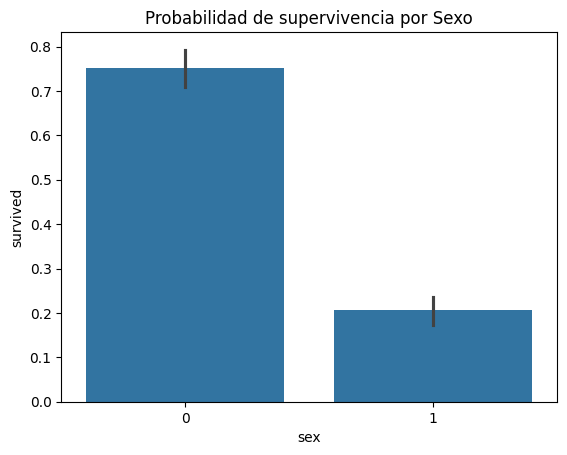

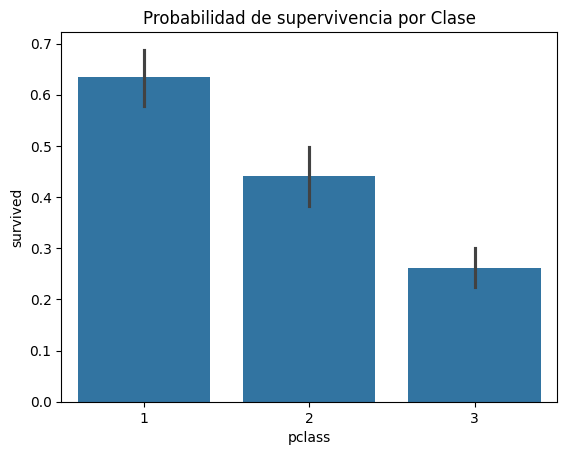

In [44]:
# 4. Visualización de datos

# Gráfica de barras para ver la supervivencia por sexo
sns.barplot(x='sex', y='survived', data=df_titanic)
plt.title('Probabilidad de supervivencia por Sexo')
plt.show()

# Gráfica de barras para ver la supervivencia por clase
sns.barplot(x='pclass', y='survived', data=df_titanic)
plt.title('Probabilidad de supervivencia por Clase')
plt.show()

In [45]:
# 5. Prueba t-test

# Nos aseguramos que edad tenga el formato correcto
df_titanic['age'] = pd.to_numeric(df_titanic['age'], errors='coerce')
df_titanic = df_titanic.dropna(subset=['age'])

# Separamos los grupos
edad_sobrevive = df_titanic[df_titanic['survived'] == 1]['age']
edad_no_sobrevive = df_titanic[df_titanic['survived'] == 0]['age']

# Ejecutamos el t-test
t_stat, p_val = stats.ttest_ind(edad_sobrevive, edad_no_sobrevive)

print(f"Resultado t-test para la Edad: t={t_stat:.4f}, p-value={p_val:.4f}")

Resultado t-test para la Edad: t=-1.8555, p-value=0.0638


In [46]:
# 6. División de datos

# Seleccionamos las columnas para nuestro eje x, y nuestra variable objetivo y
X = df_titanic[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']]
y = df_titanic['survived']

# Dividimos 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Datos divididos correctamente")

Datos divididos correctamente


In [47]:
# 7. Creación del modelo

# Creamos y entrenamos el modelo
modelo_log = LogisticRegression(max_iter=1000)
modelo_log.fit(X_train, y_train)

print("Modelo de Regresión Logística entrenado")

Modelo de Regresión Logística entrenado


In [ ]:
# 8. Estimación de los coeficientes y los odds ratio

coeficientes = pd.DataFrame(modelo_log.coef_[0], X.columns, columns=['Coeficiente'])

# Calculamos los Odds Ratio
coeficientes['Odds Ratio'] = np.exp(coeficientes['Coeficiente'])

print(coeficientes)

        Coeficiente  Odds Ratio
pclass    -1.169060    0.310659
sex       -2.566516    0.076803
age       -0.042647    0.958249
sibsp     -0.458269    0.632377
parch      0.106183    1.112025
fare       0.001395    1.001396


### Conclusión
**Variables más significativas:** El género y la clase social fueron los predictores más determinantes. Los Odds Ratio tan bajos para estas variables muestran que las mujeres y los pasajeros de primera clase tuvieron una ventaja estadística clara.

**Impacto de la edad y de la familia:** La edad tuvo un impacto negativo muy leve (0.95), indicando que los pasajeros más jóvenes tenían una ventaja mínima. Por otro lado, contar con familiares directos parece haber ayudado positivamente en la probabilidad del rescate

**Efectividad del modelo:** El modelo de regresión logística es efectivo para identificar patrones históricos. Sin embargo, para mejorar la precisión, se podrían agrupar las edades en rangos o si alguna otra variable influyo en los resultados recapitulados
